# NLPstudy_01 - NSMC LSTM 감성 분석

- 데이터셋: NSMC (학습 150,000건 / 테스트 50,000건)
- 목표: Bidirectional LSTM으로 감성 분석 구현, Test Accuracy 85% 이상 달성
-  기술: Python, TensorFlow/Keras, KoNLPy (Okt), NSMC

---
# 0. 라이브러리 설치 및 import

In [1]:
!pip install -q KoNLPy

In [2]:
import numpy as np
import pandas as pd
import re
import time
import os
import matplotlib.pyplot as plt

from konlpy.tag import Okt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 시드 설정
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

---
# 1. 데이터 로드

## 1.1 데이터셋 로드

In [3]:
DATA_TRAIN_PATH = tf.keras.utils.get_file(
    "ratings_train.txt",
    "https://raw.github.com/ironmanciti/Infran_NLP/main/data/naver_movie/ratings_train.txt"
)
DATA_TEST_PATH = tf.keras.utils.get_file(
    "ratings_test.txt",
    "https://raw.github.com/ironmanciti/Infran_NLP/main/data/naver_movie/ratings_test.txt"
)

## 1.2 train / test 분할

In [4]:
train_data = pd.read_csv(DATA_TRAIN_PATH, delimiter='\t', quoting=3)
test_data  = pd.read_csv(DATA_TEST_PATH,  delimiter='\t', quoting=3)

print("train:", train_data.shape)
print("test: ", test_data.shape)
train_data.head()

train: (150000, 3)
test:  (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [5]:
test_data.head()

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


---
# 2. 전처리 파이프라인


## 2.1. 결측치 제거
- document 컬럼 NaN 및 빈 문자열 제거 (dropna + 조건 필터링)

In [6]:
# NaN 제거
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

# 빈 문자열 제거 (document 컬럼)
train_data = train_data[train_data['document'].str.strip() != '']
test_data  = test_data[test_data['document'].str.strip() != '']

# null 확인
print(train_data.isnull().sum())
print(test_data.isnull().sum())
print("train:", train_data.shape, "/ test:", test_data.shape)

id          0
document    0
label       0
dtype: int64
id          0
document    0
label       0
dtype: int64
train: (149995, 3) / test: (49997, 3)


## 2.2. 특수문자 제거/형태소 분석
- re.sub("[^가-힣 ]", "", text) — 한글·공백만 유지
- KoNLPy Okt.pos() — Noun, Verb, Adjective만 추출


In [7]:
okt = Okt()

def preprocessing(sentence):
    # (추가) : 불용어
    stop_words = ['이', '가', '은', '는', '을', '를', '의', '에', '도',
                  '로', '으로', '와', '과', '하다', '있다', '되다', '이다']  # ← 추가

    # 특수문자 제거 — 한글·공백만 유지
    sentence = re.sub('\\\\n', ' ', str(sentence))
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)
    sentence = sentence.strip()

    # 형태소 분석 — Noun, Verb, Adjective만 추출 (stem=True로 어간 추출)
    ALLOWED_POS = {'Noun', 'Verb', 'Adjective', 'Adverb'}  # Adverb 추가

    tokens = okt.pos(sentence, stem=False)
    result = [word for word, pos in tokens if pos in ALLOWED_POS]

    return result

# 동작 확인
print(preprocessing("이 영화 진짜 재미있고 감동적이었어요!"))

['영화', '진짜', '재미있다', '감동']


## 2.3. 길이 필터링
- 형태소 1개 이하 문장 제거, 처리 후 CSV 저장 (재사용)

In [8]:
%%time

# 전처리 결과 저장 파일 경로
TRAIN_CACHE = 'train_preprocessed.csv'
TEST_CACHE  = 'test_preprocessed.csv'

# 이미 전처리된 파일이 있으면 재사용 (시간 절약)
if os.path.exists(TRAIN_CACHE) and os.path.exists(TEST_CACHE):
    print("캐시 파일 로드 중...")
    train_df = pd.read_csv(TRAIN_CACHE)
    test_df  = pd.read_csv(TEST_CACHE)
    train_sentences = [s.split() for s in train_df['document']]
    train_labels    = train_df['label'].values
    test_sentences  = [s.split() for s in test_df['document']]
    test_labels     = test_df['label'].values
    print(f"캐시 로드 완료 — train: {len(train_sentences)}, test: {len(test_sentences)}")

else:
    train_sentences, train_labels = [], []
    test_sentences,  test_labels  = [], []

    start = time.time()

    # 훈련 데이터 전처리
    for i, (sent, label) in enumerate(zip(train_data['document'], train_data['label'])):
        if i % 10000 == 0:
            print(f"Train processed = {i}")
        tokens = preprocessing(sent)
        # 길이 필터링 - 형태소 1개 이하 문장 제거
        if len(tokens) > 1:
            train_sentences.append(tokens)
            train_labels.append(label)

    # 테스트 데이터 전처리
    for i, (sent, label) in enumerate(zip(test_data['document'], test_data['label'])):
        if i % 10000 == 0:
            print(f"Test processed = {i}")
        tokens = preprocessing(sent)
        if len(tokens) > 1:
            test_sentences.append(tokens)
            test_labels.append(label)

    print(f"\n전처리 완료: {time.time() - start:.1f}초")
    print(f"train: {len(train_sentences)}, test: {len(test_sentences)}")

    # 전처리 결과 CSV 저장 (재사용)
    pd.DataFrame({
        'document': [' '.join(s) for s in train_sentences],
        'label': train_labels
    }).to_csv(TRAIN_CACHE, index=False)

    pd.DataFrame({
        'document': [' '.join(s) for s in test_sentences],
        'label': test_labels
    }).to_csv(TEST_CACHE, index=False)

    print("전처리 결과 CSV 저장 완료")

Train processed = 0
Train processed = 10000
Train processed = 20000
Train processed = 30000
Train processed = 40000
Train processed = 50000
Train processed = 60000
Train processed = 70000
Train processed = 80000
Train processed = 90000
Train processed = 100000
Train processed = 110000
Train processed = 120000
Train processed = 130000
Train processed = 140000
Test processed = 0
Test processed = 10000
Test processed = 20000
Test processed = 30000
Test processed = 40000

전처리 완료: 718.3초
train: 138099, test: 46186
전처리 결과 CSV 저장 완료
CPU times: user 12min 7s, sys: 1.85 s, total: 12min 9s
Wall time: 11min 58s


## 2.4. 레이블 numpy array 변환

In [9]:
train_labels = np.array(train_labels)
test_labels  = np.array(test_labels)

print("train_labels shape:", train_labels.shape)
print("test_labels shape: ", test_labels.shape)

# 레이블 분포 확인
print("\ntrain 긍정/부정 비율:")
print(pd.Series(train_labels).value_counts())

train_labels shape: (138099,)
test_labels shape:  (46186,)

train 긍정/부정 비율:
0    69325
1    68774
Name: count, dtype: int64


---
# 3. 텍스트 전처리 (Tokenizer + Padding)

## 3.1. Tokenizer 생성 & 학습

In [10]:
MAX_VOCAB = 30000  # 과제 가이드라인: num_words=30000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_sentences)  # train 데이터로만 학습!

print(f"전체 단어 수: {len(tokenizer.word_index)}")
print(f"사용할 단어 수: {MAX_VOCAB}")

전체 단어 수: 40152
사용할 단어 수: 30000


## 3.2. 텍스트 → 정수 시퀀스 변환

In [11]:
train_sequences = tokenizer.texts_to_sequences(train_sentences)
test_sequences  = tokenizer.texts_to_sequences(test_sentences)

print("원본:",  train_sentences[0])
print("시퀀스:", train_sequences[0])

원본: ['더빙', '진짜', '짜증나다', '목소리']
시퀀스: [288, 9, 154, 429]


## 3.3. MAX_LEN 결정 — 95th 퍼센타일 기준

평균 길이:     7.8
최대 길이:     67
95th percentile: 22


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53248 (\N{HANGUL SYLLABLE KWEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

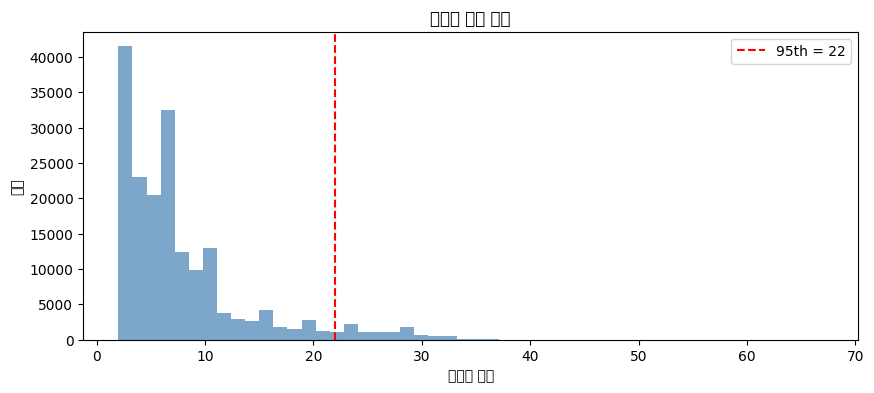

In [12]:
lengths = [len(s) for s in train_sequences + test_sequences]

print(f"평균 길이:     {np.mean(lengths):.1f}")
print(f"최대 길이:     {np.max(lengths)}")
print(f"95th percentile: {np.percentile(lengths, 95):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', alpha=0.7)
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='--',
            label=f"95th = {np.percentile(lengths, 95):.0f}")
plt.xlabel('시퀀스 길이')
plt.ylabel('빈도')
plt.title('시퀀스 길이 분포')
plt.legend()
plt.show()

## 3.4. 패딩 (pad_sequences)

과제 가이드라인: `maxlen=100`

In [13]:
MAX_LEN = 150  # 100 -> 150

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN,
                             padding='post', truncating='post')
test_padded  = pad_sequences(test_sequences,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print("train_padded shape:", train_padded.shape)
print("test_padded shape: ", test_padded.shape)
print("\n첫 번째 샘플:", train_padded[0])

train_padded shape: (138099, 150)
test_padded shape:  (46186, 150)

첫 번째 샘플: [288   9 154 429   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0]


## 3.5. 역변환으로 전처리 결과 검증

In [14]:
reverse_word_index = dict([(v, k) for (k, v) in tokenizer.word_index.items()])

def decode_sentence(sequence):
    return ' '.join([reverse_word_index.get(i, '<pad>') for i in sequence if i != 0])

print("원본 문장:",  train_sentences[4])
print("역변환 결과:", decode_sentence(train_padded[4]))

원본 문장: ['몬페', '익살스럽다', '연기', '돋보이다', '영화', '스파이더맨', '늙다', '보이다', '커스틴', '던스트', '이쁘다', '보이다']
역변환 결과: 몬페 익살스럽다 연기 돋보이다 영화 스파이더맨 늙다 보이다 커스틴 던스트 이쁘다 보이다


---
# Phase 4. 모델링 & 예측

## 4.1 모델 정의

과제 권장 구조: Embedding → BiLSTM(64, return_sequences=True) → Dropout → BiLSTM(32) → Dropout → Dense(64) → Dense(1)

In [15]:
model = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),         # 256 -> 128

    # 첫 번째 BiLSTM: return_sequences=True → 두 번째 LSTM으로 전체 시퀀스 전달
    Bidirectional(LSTM(128, return_sequences=True)),          # 64 → 128
    Dropout(0.4),

     # 두 번째 BiLSTM: 최종 hidden state만 반환
    Bidirectional(LSTM(64)),                                  # 32 → 64
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.build(input_shape=(None, MAX_LEN))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,275,841 (16.31 MB)

 Trainable params: 4,275,841 (16.31 MB)

 Non-trainable params: 0 (0.00 B)

## 4.2 모델 훈련

콜백 설정:
- `ReduceLROnPlateau`: val_loss 개선 없으면 학습률 자동 감소 (+1~2%)
- `EarlyStopping`: 과적합 방지, 최적 가중치 자동 복원

In [16]:

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',   # 정확도 기준으로 최고 모델 저장
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',       # val_accuracy → val_loss 로 변경
        patience=7,               # 4 → 7 로 변경
        restore_best_weights=True,
        verbose=1
    )
]

In [17]:
%%time

history = model.fit(
    train_padded, train_labels,
    epochs=30,
    batch_size=64,
    validation_data=(test_padded, test_labels),
    callbacks=callbacks,   # 리스트로 한번에
    verbose=1
)

Epoch 1/30
2157/2158 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7736 - loss: 0.4545
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2158/2158 ━━━━━━━━━━━━━━━━━━━━ 93s 39ms/step - accuracy: 0.8121 - loss: 0.4062 - val_accuracy: 0.8333 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 2/30
1420/2158 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.8577 - loss: 0.3293

KeyboardInterrupt: 

## 4.3.학습 곡선 시각화

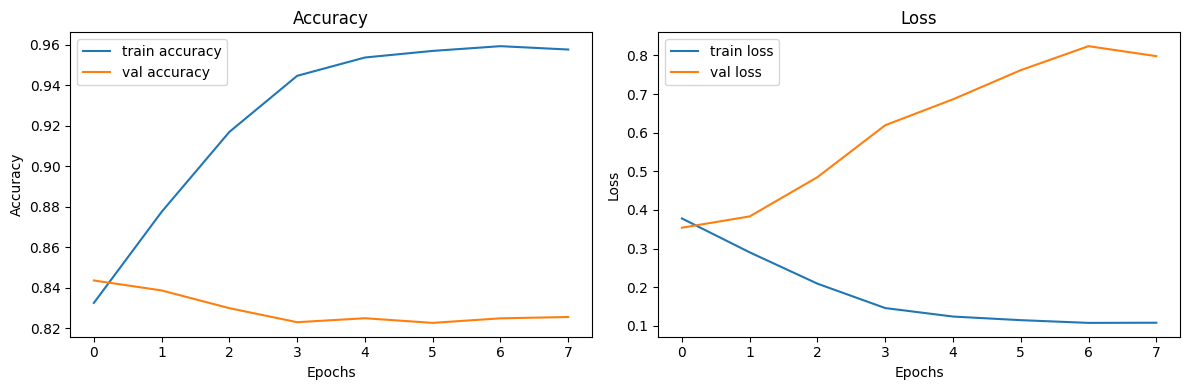

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='val accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_title('Accuracy')

ax2.plot(history.history['loss'],     label='train loss')
ax2.plot(history.history['val_loss'], label='val loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_title('Loss')

plt.tight_layout()
plt.show()

## 4.4.최종 성능 평가 (model.evaluate)

In [26]:
loss, accuracy = model.evaluate(test_padded, test_labels, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss:     0.3540
Test Accuracy: 0.8437 (84.37%)


## 4.5.Confusion Matrix

1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{H

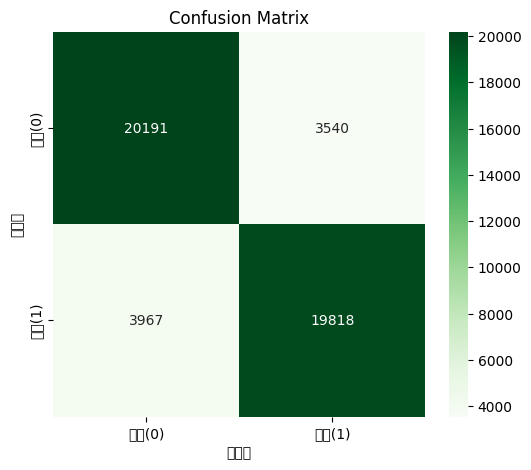

In [33]:
y_pred = (model.predict(test_padded) >= 0.5).astype(int)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['부정(0)', '긍정(1)'],
            yticklabels=['부정(0)', '긍정(1)'])
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('Confusion Matrix')
plt.show()

## 4.6.새 문장 예측

In [ ]:
def predict_sentiment(text):
    # 훈련 때와 동일한 전처리 파이프라인 적용
    tokens     = preprocessing(text)
    seq        = tokenizer.texts_to_sequences([tokens])
    padded     = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob       = model.predict(padded, verbose=0)[0][0]
    label      = 'positive 😊' if prob >= 0.5 else 'negative 😞'
    print(f"문장:  {text}")
    print(f"형태소: {tokens}")
    print(f"확률:  {prob:.4f}  →  {label}")
    print()

predict_sentiment('이 영화는 정말 짜증나서 못 보겠다')
predict_sentiment('오랜만에 접한 수작')
predict_sentiment('배우들 연기가 너무 좋고 감동적이었어요')
predict_sentiment('돈 아깝고 시간 낭비 최악의 영화')

---
## + ) Embedding Layer 시각화

- Embedding projector: https://projector.tensorflow.org/

In [34]:
e = model.layers[0]             # Embedding 레이어
weights = e.get_weights()[0]    # 가중치 추출
print("Embedding weights shape:", weights.shape)

Embedding weights shape: (30000, 128)


In [35]:
# 상위 1000개 단어 벡터 저장 (Embedding Projector 업로드용)
out_v = open('vects.tsv', 'w', encoding='utf-8')
out_m = open('meta.tsv',  'w', encoding='utf-8')

for i in range(1, 1000):
    word       = tokenizer.index_word.get(i, '?')
    embeddings = weights[i]
    out_m.write(word + '\n')
    out_v.write('\t'.join([str(x) for x in embeddings]) + '\n')

out_v.close()
out_m.close()
print("vects.tsv, meta.tsv 저장 완료")
print("→ https://projector.tensorflow.org/ 에 업로드해서 시각화 확인")

vects.tsv, meta.tsv 저장 완료
→ https://projector.tensorflow.org/ 에 업로드해서 시각화 확인
